In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier,IsolationForest
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (r2_score, mean_squared_error,
                             classification_report, roc_auc_score,accuracy_score,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay,f1_score)
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Read the dataset from the current folder
df = pd.read_csv("vgsales_input.csv")

# Show first rows to check if loading worked
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
# Check basic information about the dataset
df.info()

# Check first descriptive statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


# Data Cleaning

# Missing values

In [5]:
# Check missing values per column
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

# Deal with them (delete everything below 1 million, research the rest)

In [6]:
# Filter rows where Publisher is missing (NaN)
missing_publisher = df[df["Publisher"].isna()]

# Sort by Global Sales descending
missing_publisher = missing_publisher.sort_values(by="Global_Sales", ascending=False)

# Display all rows
missing_publisher

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
1303,1305,Triple Play 99,PS,NaN,Sports,NaN,0.81,0.55,0.00,0.10,1.46
1662,1664,Shrek / Shrek 2 2-in-1 Gameboy Advance Video,GBA,2007.0,Misc,NaN,0.87,0.32,0.00,0.02,1.21
2222,2224,Bentley's Hackpack,GBA,2005.0,Misc,NaN,0.67,0.25,0.00,0.02,0.93
3159,3161,Nicktoons Collection: Game Boy Advance Video V...,GBA,2004.0,Misc,NaN,0.46,0.17,0.00,0.01,0.64
3166,3168,SpongeBob SquarePants: Game Boy Advance Video ...,GBA,2004.0,Misc,NaN,0.46,0.17,0.00,0.01,0.64
3766,3768,SpongeBob SquarePants: Game Boy Advance Video ...,GBA,2004.0,Misc,NaN,0.38,0.14,0.00,0.01,0.53
4145,4147,Sonic the Hedgehog,PS3,NaN,Platform,NaN,0.00,0.48,0.00,0.00,0.48
4526,4528,The Fairly Odd Parents: Game Boy Advance Video...,GBA,2004.0,Misc,NaN,0.31,0.11,0.00,0.01,0.43
4635,4637,The Fairly Odd Parents: Game Boy Advance Video...,GBA,2004.0,Misc,NaN,0.30,0.11,0.00,0.01,0.42


# Delete all missing publisher with less than 1 mio global sales

In [7]:
# Remove rows where Publisher is missing AND Global_Sales < 1
df = df[~(
    df["Publisher"].isna() & 
    (df["Global_Sales"] < 1)
)]

In [8]:
# Check remaining missing publishers
df[df["Publisher"].isna()].sort_values(by="Global_Sales", ascending=False)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.0,0.41,3.00
1303,1305,Triple Play 99,PS,NaN,Sports,NaN,0.81,0.55,0.0,0.10,1.46
1662,1664,Shrek / Shrek 2 2-in-1 Gameboy Advance Video,GBA,2007.0,Misc,NaN,0.87,0.32,0.0,0.02,1.21


# manually plug in the publishers

In [9]:
# Update publisher for WWE Smackdown vs. Raw 2006 (PS2)
df.loc[
    (df["Name"] == "wwe Smackdown vs. Raw 2006") &
    (df["Platform"] == "PS2"),
    "Publisher"
] = "THQ"


# Update publisher for Triple Play 99 (PS)
df.loc[
    (df["Name"] == "Triple Play 99") &
    (df["Platform"] == "PS"),
    "Publisher"
] = "Electronic Arts"


# Update publisher for Shrek / Shrek 2 2-in-1 Gameboy Advance Video (GBA)
df.loc[
    (df["Name"] == "Shrek / Shrek 2 2-in-1 Gameboy Advance Video") &
    (df["Platform"] == "GBA"),
    "Publisher"
] = "Majesco Entertainment"

In [10]:
# Check if publishers were updated correctly
df.loc[
    df["Name"].isin([
        "wwe Smackdown vs. Raw 2006",
        "Triple Play 99",
        "Shrek / Shrek 2 2-in-1 Gameboy Advance Video"
    ]),
    ["Name", "Platform", "Publisher"]
]

,Name,Platform,Publisher
470,wwe Smackdown vs. Raw 2006,PS2,THQ
1303,Triple Play 99,PS,Electronic Arts
1662,Shrek / Shrek 2 2-in-1 Gameboy Advance Video,GBA,Majesco Entertainment


# now for years

In [11]:
# Filter rows where Year is missing
missing_year = df[df["Year"].isna()]

# Sort by Global Sales descending
missing_year = missing_year.sort_values(by="Global_Sales", ascending=False)

# Show full list
pd.set_option("display.max_rows", None)
missing_year

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,THQ,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
624,625,Rock Band,X360,NaN,Misc,Electronic Arts,1.93,0.34,0.00,0.21,2.48
649,650,Frogger's Adventures: Temple of the Frog,GBA,NaN,Adventure,Konami Digital Entertainment,2.15,0.18,0.00,0.07,2.39
652,653,LEGO Indiana Jones: The Original Adventures,Wii,NaN,Action,LucasArts,1.54,0.63,0.00,0.22,2.39
711,713,Call of Duty 3,Wii,NaN,Shooter,Activision,1.19,0.84,0.00,0.23,2.26
782,784,Rock Band,Wii,NaN,Misc,MTV Games,1.35,0.56,0.00,0.20,2.11


In [12]:
# Remove rows where Year is missing AND Global_Sales < 1
df = df[~(
    df["Year"].isna() &
    (df["Global_Sales"] < 1)
)]

In [13]:
# Check remaining missing Year values
df[df["Year"].isna()].sort_values(by="Global_Sales", ascending=False)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,THQ,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
624,625,Rock Band,X360,NaN,Misc,Electronic Arts,1.93,0.34,0.00,0.21,2.48
649,650,Frogger's Adventures: Temple of the Frog,GBA,NaN,Adventure,Konami Digital Entertainment,2.15,0.18,0.00,0.07,2.39
652,653,LEGO Indiana Jones: The Original Adventures,Wii,NaN,Action,LucasArts,1.54,0.63,0.00,0.22,2.39
711,713,Call of Duty 3,Wii,NaN,Shooter,Activision,1.19,0.84,0.00,0.23,2.26
782,784,Rock Band,Wii,NaN,Misc,MTV Games,1.35,0.56,0.00,0.20,2.11


In [14]:
# Update missing years based on Rank (unique identifier here)

rank_to_year = {
    180: 2003,   # Madden NFL 2004 (PS2)
    378: 2003,  # FIFA Soccer 2004 (PS2) -> TODO: add the year you researched
    432: 2008,   # LEGO Batman: The Videogame (Wii)
    471: 2005,   # wwe Smackdown vs. Raw 2006 (PS2)
    608: 1980,   # Space Invaders (2600)
    625: 2007,   # Rock Band (X360)
    650: 2001,   # Frogger's Adventures: Temple of the Frog (GBA)
    653: 2008,   # LEGO Indiana Jones: The Original Adventures
    713: 2006,   # Call of Duty 3
    784: 2008,   # Rock Band (second entry)
    1128: 2012   # Call of Duty: Black Ops
}

for rank, year in rank_to_year.items():
    df.loc[df["Rank"] == rank, "Year"] = year

In [15]:
# Check remaining missing Year values
df[df["Year"].isna()].sort_values(by="Global_Sales", ascending=False)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
1133,1135,Rock Band,PS3,NaN,Misc,Electronic Arts,0.99,0.41,0.0,0.22,1.62
1303,1305,Triple Play 99,PS,NaN,Sports,Electronic Arts,0.81,0.55,0.0,0.10,1.46
1433,1435,LEGO Harry Potter: Years 5-7,Wii,NaN,Action,Warner Bros. Interactive Entertainment,0.76,0.47,0.0,0.13,1.36
1498,1500,LEGO Batman: The Videogame,PSP,NaN,Action,Warner Bros. Interactive Entertainment,0.57,0.46,0.0,0.28,1.32
1513,1515,Adventure,2600,NaN,Adventure,Atari,1.21,0.08,0.0,0.01,1.30
1585,1587,Combat,2600,NaN,Action,Atari,1.17,0.07,0.0,0.01,1.25
1649,1651,NASCAR Thunder 2003,PS2,NaN,Racing,Unknown,0.60,0.46,0.0,0.16,1.22
1697,1699,Hitman 2: Silent Assassin,XB,NaN,Action,Eidos Interactive,0.76,0.38,0.0,0.05,1.19
1837,1839,Rock Band,PS2,NaN,Misc,Electronic Arts,0.71,0.06,0.0,0.35,1.11
1990,1992,Legacy of Kain: Soul Reaver,PS,NaN,Action,Eidos Interactive,0.58,0.40,0.0,0.07,1.04


In [16]:
# Update missing years based on Rank (unique identifier here)

rank_to_year = {
    1135: 2008,  # Rock Band (PS3)
    1305: 1998,  # Triple Play 99 (PS)
    1435: 2011,  # LEGO Harry Potter: Years 5-7 (Wii)
    1500: 2008,  # LEGO Batman: The Videogame (PSP)
    1515: 1980,  # Adventure (2600)
    1587: 1980,  # Combat (2600)
    1651: 2002,  # NASCAR Thunder 2003 (PS2)
    1699: 2002,  # Hitman 2: Silent Assassin (XB)
    1839: 2007,  # Rock Band (PS2)
    1992: 2012,  # Legacy of Kain: Soul Reaver (PS)
    2021: 1997   # Donkey Kong Land III (GB)
}

for rank, year in rank_to_year.items():
    df.loc[df["Rank"] == rank, "Year"] = year

In [17]:
# Check missing values per column
df.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

# Duplicates

In [18]:
# Create list of all columns except "Rank"
cols_without_rank = df.columns.drop("Rank")

In [19]:
# Count such duplicates
df.duplicated(subset=cols_without_rank).sum()

np.int64(0)

In [20]:
# Show all rows that are duplicates based on Name, Platform and years
duplicates = df[df.duplicated(subset=["Name", "Platform", "Year"], keep=False)]

duplicates.sort_values(by=["Name", "Platform"])

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
603,604,Madden NFL 13,PS3,2012.0,Sports,Electronic Arts,2.11,0.23,0.0,0.22,2.56
16127,16130,Madden NFL 13,PS3,2012.0,Sports,Electronic Arts,0.00,0.01,0.0,0.00,0.01


# Combine the obvious duplicates

In [21]:
# Define the two ranks
rank_keep = 604
rank_remove = 16130

# Define sales columns
sales_cols = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]

# Add sales from duplicate row to the row we keep
df.loc[df["Rank"] == rank_keep, sales_cols] = (
    df.loc[df["Rank"] == rank_keep, sales_cols].values +
    df.loc[df["Rank"] == rank_remove, sales_cols].values
)

# Remove the duplicate row
df = df[df["Rank"] != rank_remove]

In [22]:
df = df.drop(columns=["Rank"])

In [23]:
df[df["Name"] == "Madden NFL 13"][["Name", "Platform", "Global_Sales"]]

,Name,Platform,Global_Sales
506,Madden NFL 13,X360,2.86
603,Madden NFL 13,PS3,2.57
3730,Madden NFL 13,Wii,0.54
5588,Madden NFL 13,PSV,0.32
6792,Madden NFL 13,WiiU,0.24


# There was one year 2020, which is wrong. Manually checking showed that the release year is 2009

In [24]:
# Show all rows where Year is 2020
df[df["Year"] == 2020]

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
5957,Imagine: Makeup Artist,DS,2020.0,Simulation,Ubisoft,0.27,0.0,0.0,0.02,0.29


In [25]:
# Replace Year 2020 with 2009
df.loc[df["Year"] == 2020, "Year"] = 2009

In [26]:
# Verify no 2020 values remain
(df["Year"] == 2020).sum()

np.int64(0)

# Cleaning finished, export final dataset

In [27]:
# Save dataframe as Excel file
df.to_excel("Games_final.xlsx", index=False)

In [28]:
# Read final dataset
df = pd.read_excel("Games_final.xlsx")

# Quick check
df.head()

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


# Get descriptive statistics and dataset overview

In [29]:
# Create structure table
structure_df = pd.DataFrame({
    "Feature / Variable": df.columns,
    "Data type": df.dtypes.values,
    "Number of unique values": [df[col].nunique() for col in df.columns],
    "Example values": [df[col].dropna().unique()[:3] for col in df.columns]
})

# Display structure table
structure_df

,Feature / Variable,Data type,Number of unique values,Example values
0,Name,object,11334,"[Wii Sports, Super Mario Bros., Mario Kart Wii]"
1,Platform,object,31,"[Wii, NES, GB]"
2,Year,int64,38,"[2006, 1985, 2008]"
3,Genre,object,12,"[Sports, Platform, Racing]"
4,Publisher,object,576,"[Nintendo, Microsoft Game Studios, Take-Two In..."
5,NA_Sales,float64,409,"[41.49, 29.08, 15.85]"
6,EU_Sales,float64,305,"[29.02, 3.58, 12.88]"
7,JP_Sales,float64,244,"[3.77, 6.81, 3.79]"
8,Other_Sales,float64,157,"[8.46, 0.77, 3.31]"
9,Global_Sales,float64,623,"[82.74, 40.24, 35.82]"


In [30]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Calculate descriptive statistics
desc_stats = df[numeric_cols].describe().T

# Add variance
desc_stats["Variance"] = df[numeric_cols].var()

# Display numeric statistics table
desc_stats

,count,mean,std,min,25%,50%,75%,max,Variance
Year,16313.0,2006.398762,5.840202,1980.00,2003.00,2007.00,2010.00,2017.00,34.107961
NA_Sales,16313.0,0.267072,0.823320,0.00,0.00,0.08,0.24,41.49,0.677856
EU_Sales,16313.0,0.148276,0.509470,0.00,0.00,0.02,0.11,29.02,0.259560
JP_Sales,16313.0,0.078730,0.311682,0.00,0.00,0.00,0.04,10.22,0.097146
Other_Sales,16313.0,0.048640,0.190146,0.00,0.00,0.01,0.04,10.57,0.036155
Global_Sales,16313.0,0.542988,1.567676,0.01,0.06,0.17,0.48,82.74,2.457608


#### defining colour palette 

In [31]:
# for the global styling of all charts in the notebook
PALETTE = ['#2C3E50','#E74C3C','#3498DB','#2ECC71','#F39C12',
           '#9B59B6','#1ABC9C','#E67E22',"#E1FF02",'#E91E63',
           '#00BCD4','#8BC34A']
sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams['figure.dpi'] = 130

## making Cluster of game series and platform families 
 - we suspect that there is connection between single games within the series 
 - we suspect that different generations of a platform (e.g. PS1, PS2, PS3) complement each other in sale numbers. We will cluster model generations to model families to enable analyzing data for the whole familiy.

In [32]:
# Create Platform Family column
platform_families = {
    'Nintendo Home'      : ['NES','SNES','N64','GC','Wii','WiiU'],
    'Nintendo Handheld'  : ['GB','GBA','DS','3DS'],
    'PlayStation Home'   : ['PS','PS2','PS3','PS4'],
    'PlayStation Handheld': ['PSP','PSV'],
    'Xbox'               : ['XB','X360','XOne'],
    'Atari'              : ['2600'],
    'Sega'               : ['GEN','DC','SAT','SCD','GG'],
    'PC'                 : ['PC'],
    'Other'              : ['3DO','NG','PCFX','TG16','WS'],
}
df['Platform_Family'] = 'Other'
for family, platforms in platform_families.items():
    df.loc[df['Platform'].isin(platforms), 'Platform_Family'] = family

# Create Game Series (Game Family) column
series_map = {
    'Mario'            : ['Mario'],
    'Pokemon'          : ['Pokemon', 'Pokémon'],
    'Call of Duty'     : ['Call of Duty'],
    'Grand Theft Auto' : ['Grand Theft Auto', 'GTA'],
    'FIFA'             : ['FIFA'],
    'Final Fantasy'    : ['Final Fantasy'],
    'Zelda'            : ['Zelda'],
    'Sonic'            : ['Sonic'],
    'Halo'             : ['Halo'],
    "Assassin's Creed" : ["Assassin's Creed"],
    'Madden NFL'       : ['Madden'],
    'Gran Turismo'     : ['Gran Turismo'],
    'Need for Speed'   : ['Need for Speed'],
    'Dragon Quest'     : ['Dragon Quest'],
    'Resident Evil'    : ['Resident Evil'],
    'Donkey Kong'      : ['Donkey Kong'],
    'Battlefield'      : ['Battlefield'],
    'Kirby'            : ['Kirby'],
    'NBA 2K'           : ['NBA 2K'],
    'WWE'              : ['WWE'],
    'Wii Sports'        : ['Wii Sports'],
    'Just Dance'        : ['Just Dance'],
    'Sonic'           : ['Sonic'],
    'star Wars'         : ['Star Wars', 'StarWars', 'Star War'],
    'Tony Hawk'         : ['Tony Hawk', 'THPS', 'THUG'],
}
df['Game_Series'] = 'Standalone'
for series, keywords in series_map.items():
    mask = df['Name'].str.contains('|'.join(keywords), case=False, na=False)
    df.loc[mask, 'Game_Series'] = series
    
series_games = (df['Game_Series'] != 'Standalone').sum()


# Averaging over five years to enable more coarse analysis
df['5_Year_period'] = (df['Year'] // 5) * 5

## Research question 1: Which genres and platforms dominates global sales.

In [ ]:
# summarize sales by genre
print("\n=== GENRE SUMMARY ===")
genre_summary = df.groupby('Genre').agg(
    Total_Sales   = ('Global_Sales', 'sum'),
).sort_values('Total_Sales', ascending=False)
genre_summary['Share_%'] = (genre_summary['Total_Sales'] /
                             genre_summary['Total_Sales'].sum() * 100).round(1)
print(genre_summary.round(2))


=== GENRE SUMMARY ===
              Total_Sales  Share_%
Genre                             
Action            1734.56     19.6
Sports            1319.42     14.9
Shooter           1032.62     11.7
Role-Playing       923.83     10.4
Platform           830.16      9.4
Misc               798.40      9.0
Racing             727.98      8.2
Fighting           447.05      5.0
Simulation         389.98      4.4
Puzzle             242.21      2.7
Adventure          238.28      2.7
Strategy           173.27      2.0


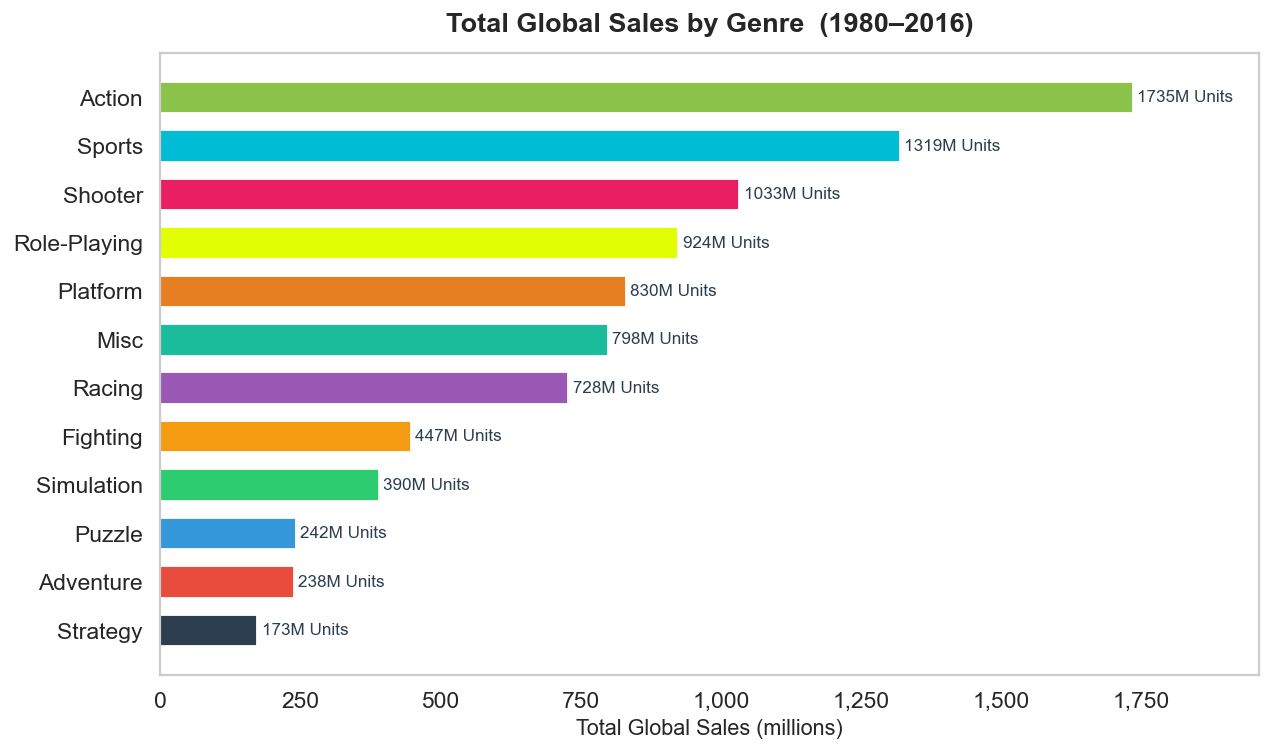

In [34]:
# plot the sales distribution by genre

genre_sales = genre_summary['Total_Sales'].sort_values()   # ascending for barh

fig, ax = plt.subplots(figsize=(10, 6))
colors_g = PALETTE[:len(genre_sales)]
bars = ax.barh(genre_sales.index, genre_sales.values,
               color=colors_g, edgecolor='white', height=0.65)

# value labels
for bar, val in zip(bars, genre_sales.values):
    ax.text(val + 8, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}M Units', va='center', fontsize=9.5, color='#2C3E50')

ax.set_xlabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Total Global Sales by Genre  (1980–2016)',
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlim(0, genre_sales.max() * 1.13)
ax.grid(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

##### Figure 1: Total global sales (millions) by genre.
Figure 1 shows total global sales by genre. Action games lead with over 1,735 million units sold, followed by Sports (1,319 M) and Shooter (1,033 M). Strategy games sit at the lower end, reflecting niche audiences.

In [35]:
#summarize sales by platform
print("\n=== TOP 10 PLATFORMS BY TOTAL SALES ===")
platform_summary = df.groupby('Platform').agg(
    Total_Sales = ('Global_Sales', 'sum'),
    Num_Games   = ('Name', 'count'),
 
).sort_values('Total_Sales', ascending=False)

print(platform_summary.head(10).round(2))


=== TOP 10 PLATFORMS BY TOTAL SALES ===
          Total_Sales  Num_Games
Platform                        
PS2           1247.51       2132
X360           972.08       1235
PS3            950.97       1304
Wii            921.10       1295
DS             818.91       2131
PS             729.89       1191
GBA            309.22        788
PSP            293.03       1198
PS4            278.10        336
PC             256.33        939


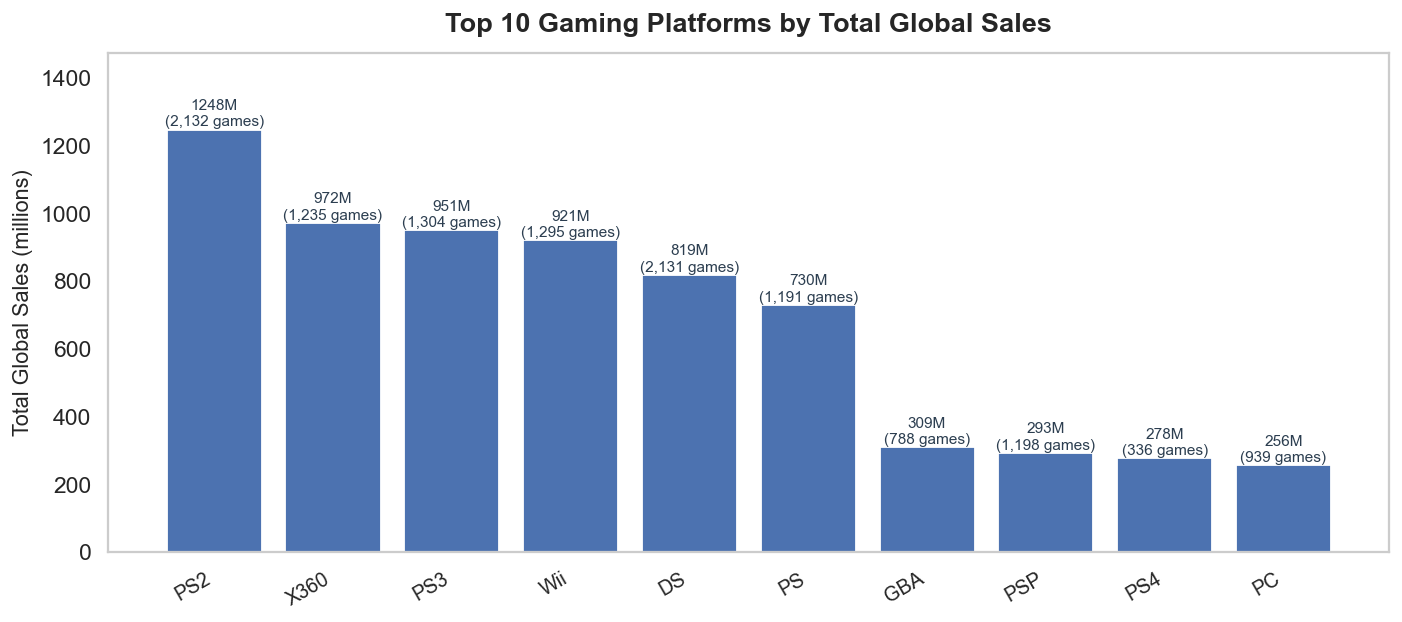

In [36]:
# plot the sales distribution by platform

top10_plat = platform_summary.head(10)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(len(top10_plat)), top10_plat['Total_Sales'].values)
           
ax.set_xticks(range(len(top10_plat)))
ax.set_xticklabels(top10_plat.index, rotation=30, ha='right', fontsize=11)
ax.set_ylabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Top 10 Gaming Platforms by Total Global Sales',
             fontsize=15, fontweight='bold', pad=12)
for i, (val, games) in enumerate(zip(top10_plat['Total_Sales'], top10_plat['Num_Games'])):
    ax.text(i, val + 10, f'{val:.0f}M\n({games:,} games)',
            ha='center', fontsize=8.5, color='#2C3E50')
ax.set_ylim(0, top10_plat['Total_Sales'].max() * 1.18)
ax.grid(False)
plt.tight_layout()
plt.show()

## Research question 2: Regional Market Differences

  North America      4,356.74   49.21%
  Europe             2,418.82   27.32%
  Japan              1,284.32   14.51%
  Other                793.47    8.96%
  ------------------------------------
  TOTAL              8,853.35  100.00%


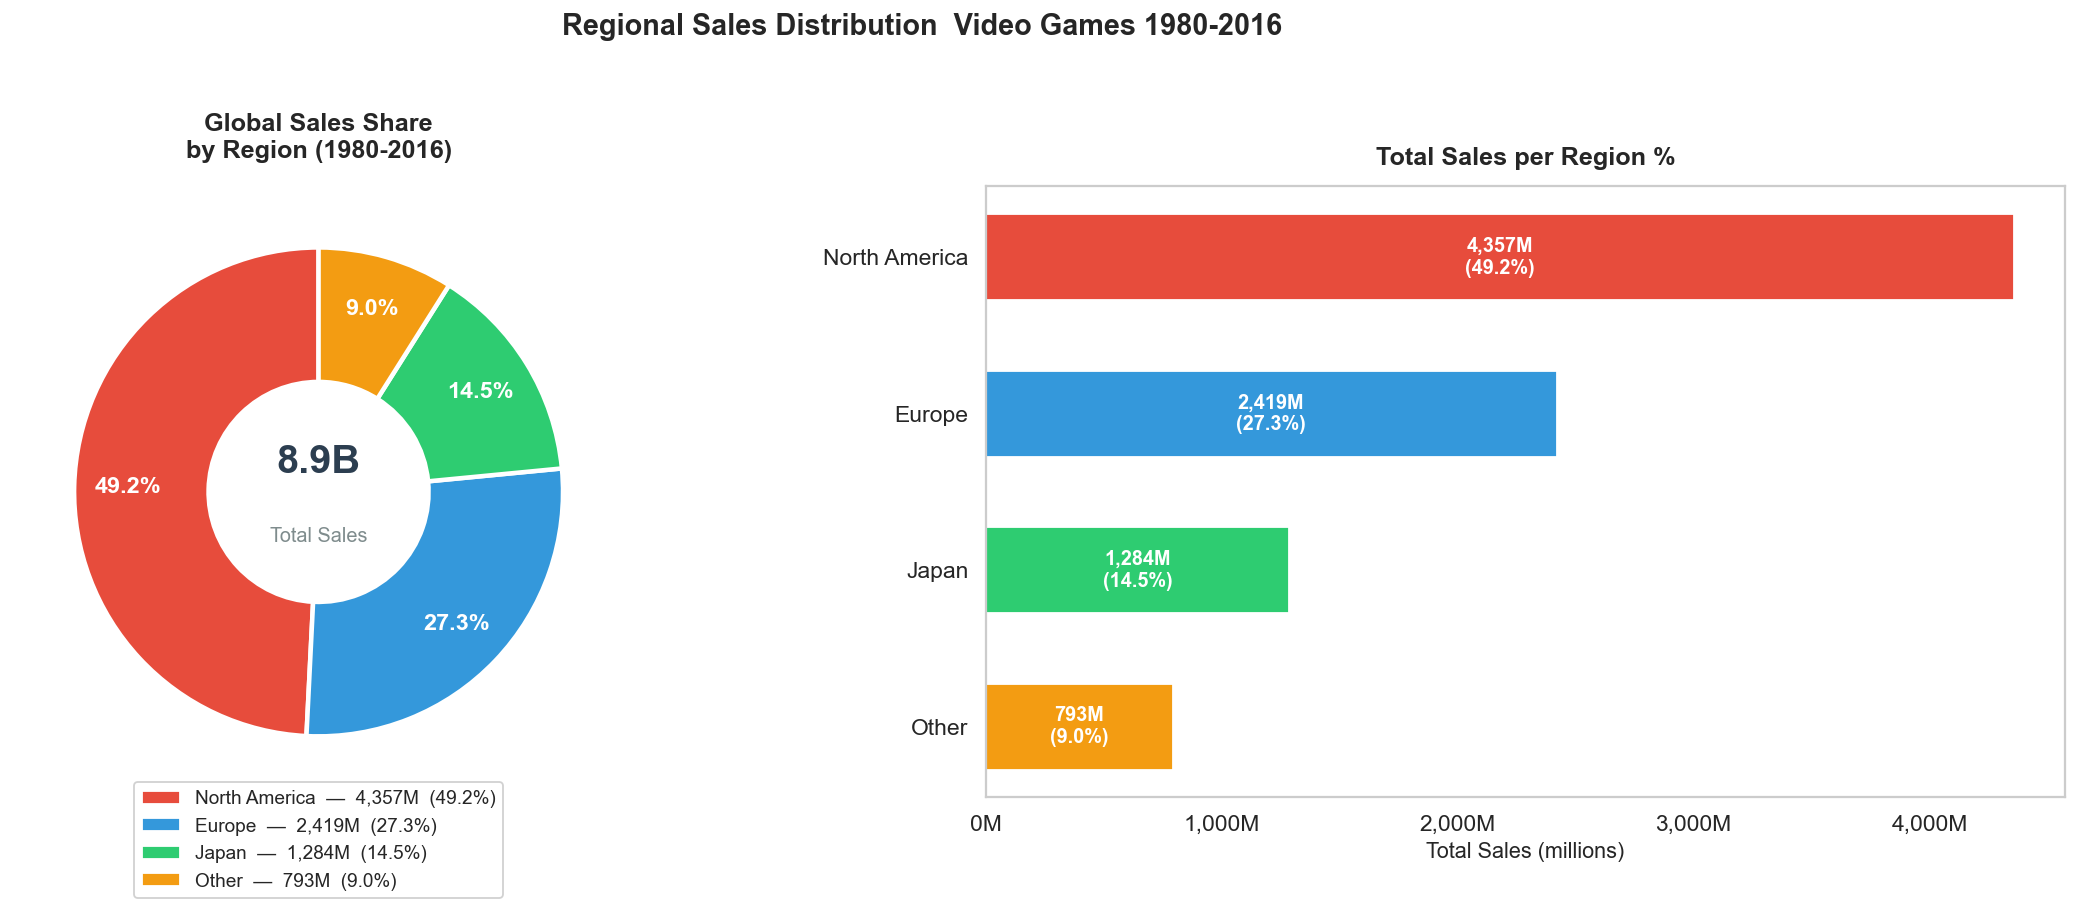

In [53]:
# Plot total sales in different regions. Plot donut chart for relative share and bar chart for absolute sales.


# Calculate total and percantages
na    = df['NA_Sales'].sum()
eu    = df['EU_Sales'].sum()
jp    = df['JP_Sales'].sum()
other = df['Other_Sales'].sum()
total = na + eu + jp + other

regions = ['North America', 'Europe', 'Japan', 'Other']
sales   = [na, eu, jp, other]
pcts    = [v / total * 100 for v in sales]
colors  = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

for r, s, p in zip(regions, sales, pcts):
    print(f"  {r:<16} {s:>10,.2f}  {p:>6.2f}%")
print(f"  {'-'*36}")
print(f"  {'TOTAL':<16} {total:>10,.2f}  {'100.00%':>7}")

#  Yearly regional breakdown 
reg_yr     = df.groupby('Year')[['NA_Sales','EU_Sales',
                                   'JP_Sales','Other_Sales']].sum()
reg_yr_pct = reg_yr.div(reg_yr.sum(axis=1), axis=0) * 100

# 2 side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(18, 7))


# left side — Donut Chart
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    sales,
    labels=None,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5),
    textprops={'fontsize': 13, 'fontweight': 'bold'}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(13)
    at.set_fontweight('bold')

# centre label showing grand total
ax.text(0,  0.12, f'{total/1000:.1f}B',
        ha='center', va='center',
        fontsize=22, fontweight='bold', color='#2C3E50')
ax.text(0, -0.18, 'Total Sales',
        ha='center', va='center',
        fontsize=11, color='#7F8C8D')

# legend with exact values
legend_labels = [f'{r}  —  {s:,.0f}M  ({p:.1f}%)'
                 for r, s, p in zip(regions, sales, pcts)]
patches = [plt.Rectangle((0,0),1,1, fc=c, ec='white') for c in colors]
ax.legend(patches, legend_labels,
          loc='lower center', bbox_to_anchor=(0.5, -0.18),
          fontsize=10.5, framealpha=0.9, ncol=1)
ax.set_title('Global Sales Share\nby Region (1980-2016)',
             fontsize=14, fontweight='bold', pad=16)

# right side — Horizontal Bar Chart
ax = axes[1]
bars = ax.barh(regions[::-1], sales[::-1],
               color=colors[::-1], edgecolor='white', height=0.55)

# value labels inside each bar
for bar, val, pct in zip(bars, sales[::-1], pcts[::-1]):
    ax.text(val / 2,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}M\n({pct:.1f}%)',
            va='center', ha='center',
            fontsize=11, fontweight='bold', color='white')

ax.set_xlabel('Total Sales (millions)', fontsize=12)
ax.set_title('Total Sales per Region %',
             fontsize=14, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{v:,.0f}M'))
ax.set_xlim(0, max(sales) * 1.05)
ax.grid(False)


plt.suptitle('Regional Sales Distribution  Video Games 1980-2016',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

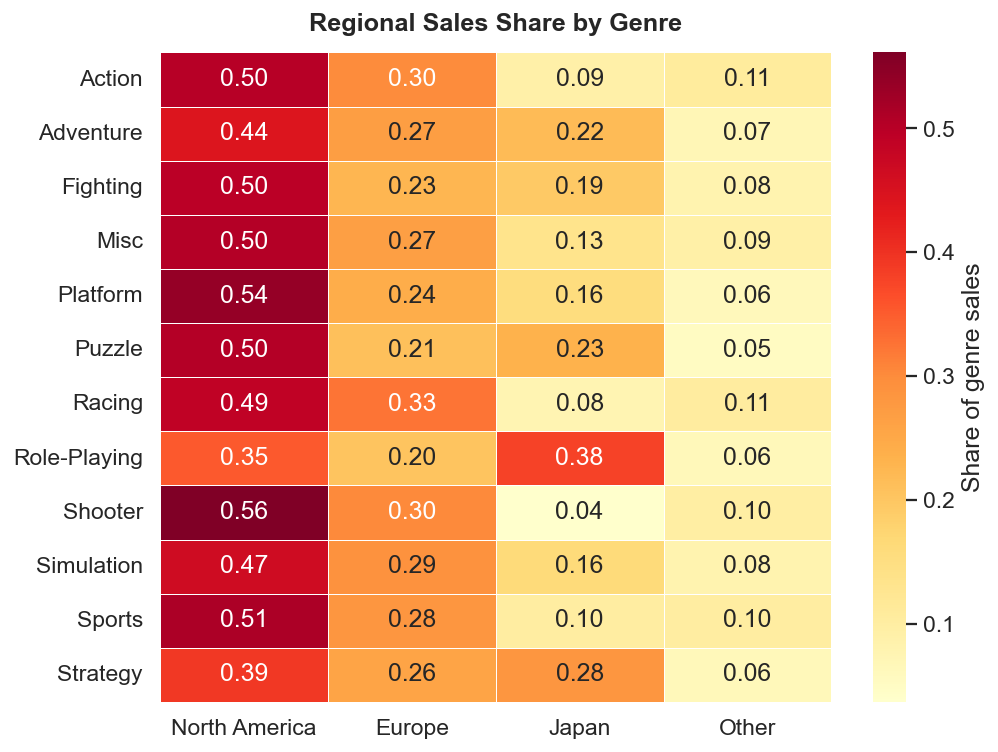

In [37]:
# Plot relative distribution of sales by genre and region

reg_genre = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
reg_genre_norm = reg_genre.div(reg_genre.sum(axis=1), axis=0)   # row-wise share
reg_genre_norm.columns = ['North America', 'Europe', 'Japan', 'Other']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    reg_genre_norm,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Share of genre sales'}
)
ax.set_title('Regional Sales Share by Genre',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

##### To test whether regional tastes differ, we computed each region's share of sales within each genre. Figure 3 visualises these shares as a heatmap.
Several patterns stand out. Japan commands a much higher share of Role-Playing genre
sales (typically >40%) compared to its modest share in Shooter or Sports genres. This is
consistent with Japan's historical strength in JRPG franchises (Final Fantasy, Dragon Quest,
Pokemon). North America dominates Shooter and Sports genres, both reflecting culturally
embedded preferences (American football simulations, first-person shooters). Europe's share is
broadly proportional across genres, with a slight over-index in Racing and Fighting.
To quantify regional similarity, we computed Pearson correlations between regional sales
vectors at the game level. NA and EU sales are strongly correlated (r = 0.77), indicating broadly
shared Western preferences. JP sales are much less correlated with NA (r = 0.33) and EU (r =
0.29), confirming that Japan constitutes a distinctly different market.

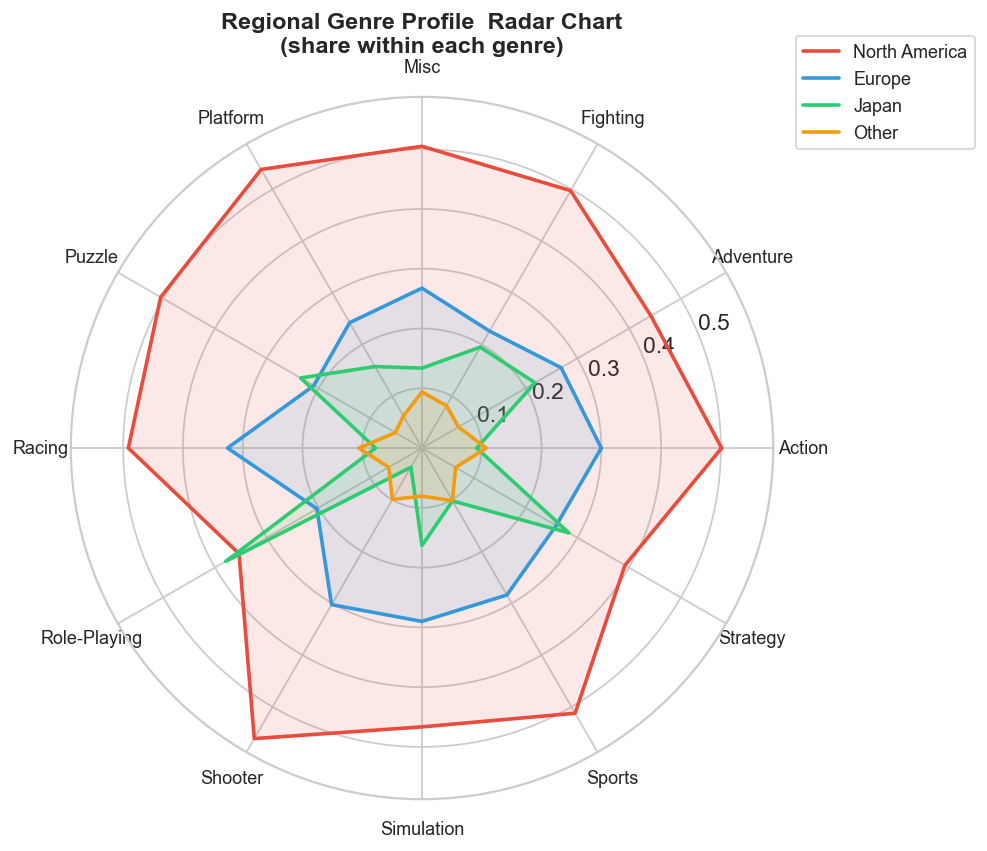

In [38]:
# radar chart of genre sales distribution across regions

radar_data = reg_genre_norm.copy()    # share per genre per region
genres_r   = list(radar_data.index)
N          = len(genres_r)
angles     = [n / float(N) * 2 * np.pi for n in range(N)]
angles    += angles[:1]              # close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_r = ['#E74C3C', '#3498DB', '#2ECC71','#F39C12']
regions  = ['North America', 'Europe', 'Japan', 'Other']

for region, color in zip(regions, colors_r):
    values  = list(radar_data[region])
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=region)
    ax.fill(angles, values, color=color, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(genres_r, size=10)
ax.set_title('Regional Genre Profile  Radar Chart\n(share within each genre)',
             fontsize=13, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

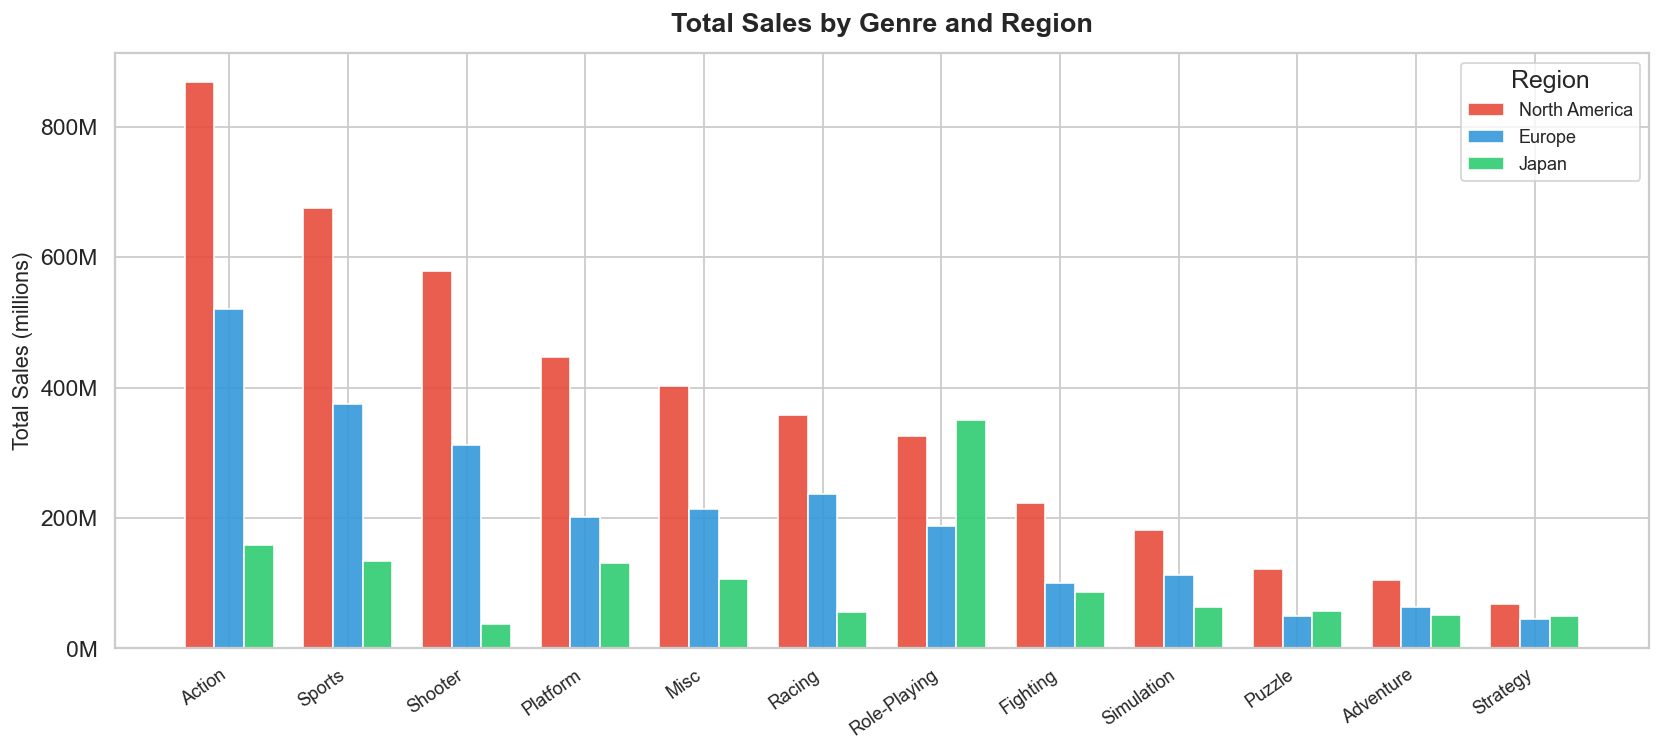

In [39]:
# bar chart of total sales by genre and region as an alternative absolute comparison

reg_genre_abs = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()
reg_genre_abs.columns = ['North America', 'Europe', 'Japan']
reg_genre_abs = reg_genre_abs.sort_values('North America', ascending=False)

x      = np.arange(len(reg_genre_abs))
width  = 0.25
colors = ['#E74C3C', '#3498DB', '#2ECC71']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (col, color) in enumerate(zip(reg_genre_abs.columns, colors)):
    ax.bar(x + i * width, reg_genre_abs[col], width,
           label=col, color=color, edgecolor='white', alpha=0.9)

ax.set_xticks(x + width)
ax.set_xticklabels(reg_genre_abs.index, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Total Sales (millions)', fontsize=12)
ax.set_title('Total Sales by Genre and Region', fontsize=15, fontweight='bold', pad=12)
ax.legend(title='Region', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}M'))
plt.tight_layout()
plt.show()

## Research question 3: Publisher Market Concentration

In [40]:
# aggregate data by publisher

pub = df.groupby('Publisher').agg(
    Total_Sales = ('Global_Sales', 'sum'),
    Num_Games   = ('Name',         'count'),
    Avg_Sales   = ('Global_Sales', 'mean'),
    First_Year  = ('Year',         'min'),
    Last_Year   = ('Year',         'max')
).sort_values('Total_Sales', ascending=False)
pub['Lifespan'] = pub['Last_Year'] - pub['First_Year']

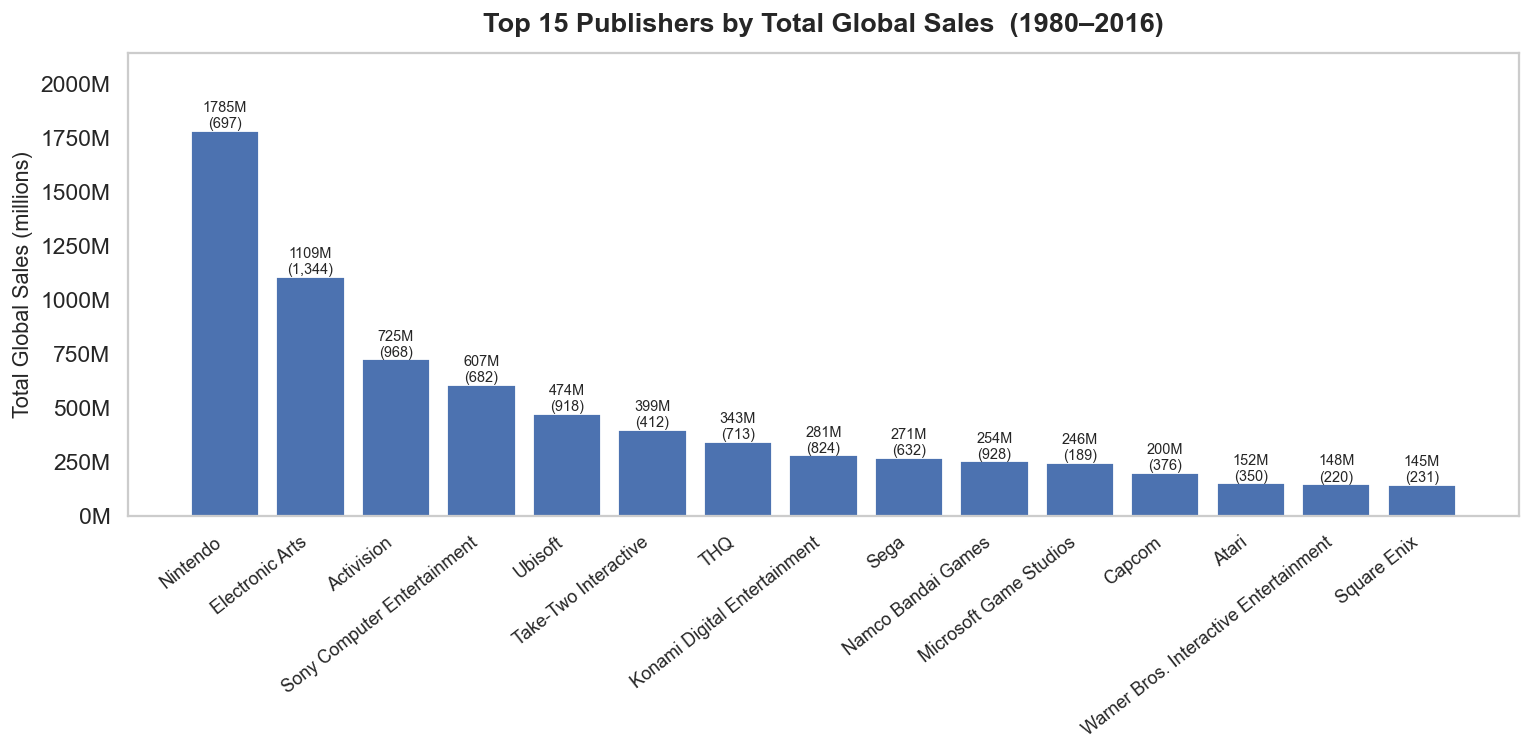

In [41]:
# Plot sales of top 15 publishers

top15 = pub.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(top15)), top15['Total_Sales'].values)
ax.set_xticks(range(len(top15)))
ax.set_xticklabels(top15.index, rotation=38, ha='right', fontsize=10)
ax.set_ylabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Top 15 Publishers by Total Global Sales  (1980–2016)',
             fontsize=15, fontweight='bold', pad=12)
for i, (val, games) in enumerate(zip(top15['Total_Sales'], top15['Num_Games'])):
    ax.text(i, val + 12, f'{val:.0f}M\n({games:,})', ha='center', fontsize=8)
ax.set_ylim(0, top15['Total_Sales'].max() * 1.20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}M'))
ax.grid(False)
plt.tight_layout()
plt.show()

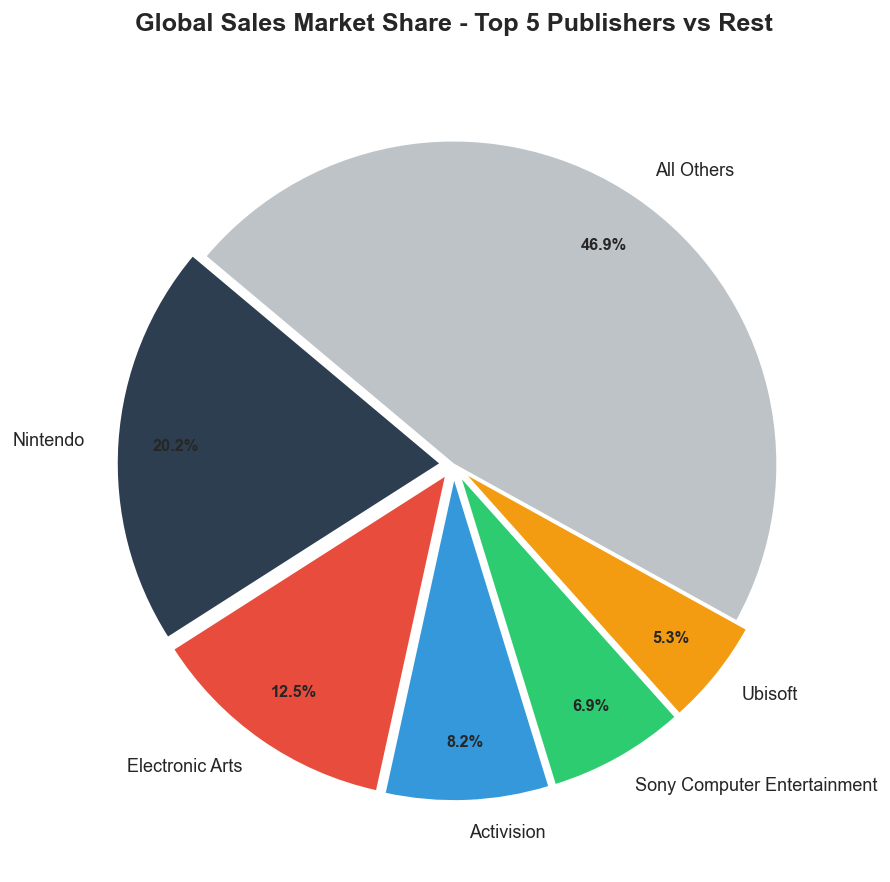

In [42]:
# pie chart for relative share of top 5 publishers

top5_sales  = pub.head(5)['Total_Sales']
rest_sales  = pub.iloc[5:]['Total_Sales'].sum()
pie_labels  = list(top5_sales.index) + ['All Others']
pie_values  = list(top5_sales.values) + [rest_sales]
pie_colors  = PALETTE[:5] + ['#BDC3C7']
explode     = [0.04] * 5 + [0]

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    pie_values, labels=pie_labels, colors=pie_colors,
    autopct='%1.1f%%', explode=explode,
    startangle=140, pctdistance=0.82,
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
ax.set_title('Global Sales Market Share - Top 5 Publishers vs Rest',
             fontsize=14, fontweight='bold', pad=16)
plt.tight_layout()
plt.show()

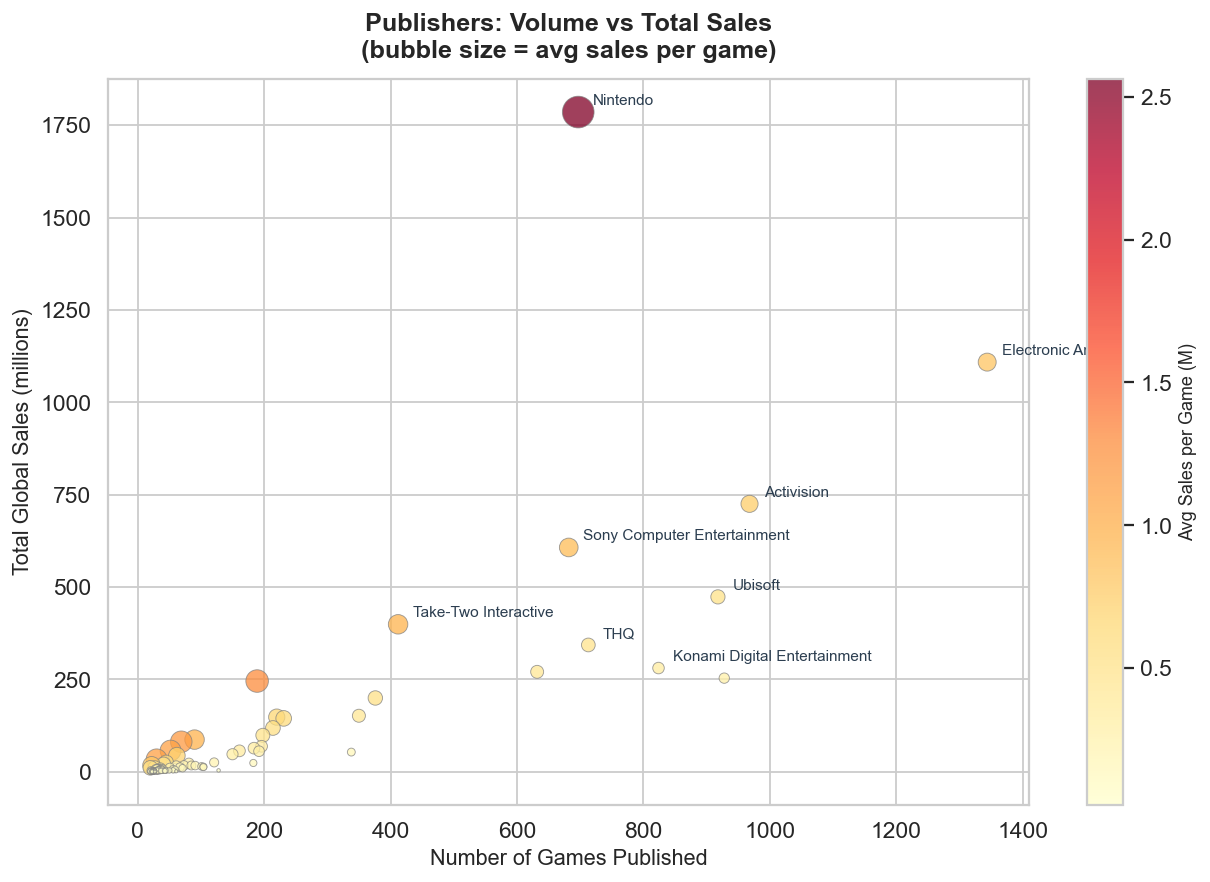

In [44]:
# Display relationship between number of games published and total sales for top 20 publishers (based on number of games published

pub_plot = pub[pub['Num_Games'] >= 20].copy()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    pub_plot['Num_Games'], pub_plot['Total_Sales'],
    s=pub_plot['Avg_Sales'] * 120,        # bubble size = avg sales
    c=pub_plot['Avg_Sales'],
    cmap='YlOrRd', alpha=0.75, edgecolors='grey', linewidth=0.5
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Avg Sales per Game (M)', fontsize=10)

# label top publishers
for pub_name, row in pub_plot.nlargest(8, 'Total_Sales').iterrows():
    ax.annotate(pub_name,
                xy=(row['Num_Games'], row['Total_Sales']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=8.5, color='#2C3E50')

ax.set_xlabel('Number of Games Published', fontsize=12)
ax.set_ylabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Publishers: Volume vs Total Sales\n(bubble size = avg sales per game)',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## Research question 3: What are the best selling games?

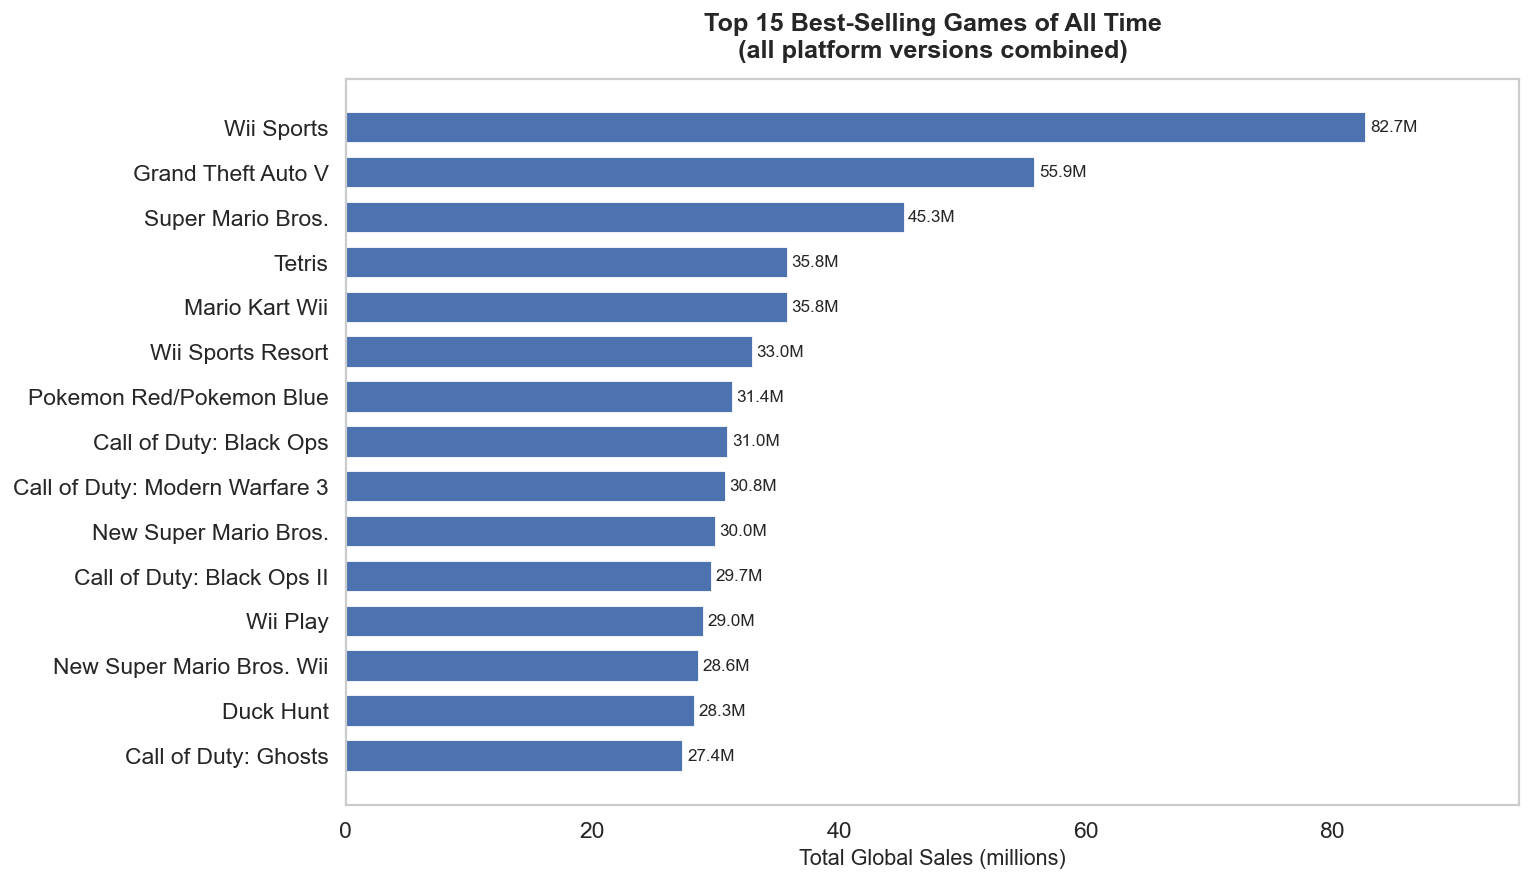

In [45]:
# plot 15 best selling games. Sale numbers are added across all platforms

best_games = df.groupby('Name').agg(
    Global_Sales=('Global_Sales','sum'),
    NA_Sales=('NA_Sales','sum'),
    EU_Sales=('EU_Sales','sum'),
    JP_Sales=('JP_Sales','sum'),
    Genre=('Genre','first'),
    Publisher=('Publisher','first')
).sort_values('Global_Sales', ascending=False)


fig, ax = plt.subplots(figsize=(12, 7))
top15 = best_games.head(15).sort_values('Global_Sales')
bars = ax.barh(top15.index, top15['Global_Sales'], 
               edgecolor='white', height=0.7)
for bar, val in zip(bars, top15['Global_Sales']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}M', va='center', fontsize=9.5)
ax.set_xlabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Top 15 Best-Selling Games of All Time\n(all platform versions combined)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(0, top15['Global_Sales'].max() * 1.15)
ax.grid(False)
plt.tight_layout()
plt.show()

## Research question 4: How did sales change over time?

In [ ]:
# Plotting sales development over time looking at regions, genres and number of games released

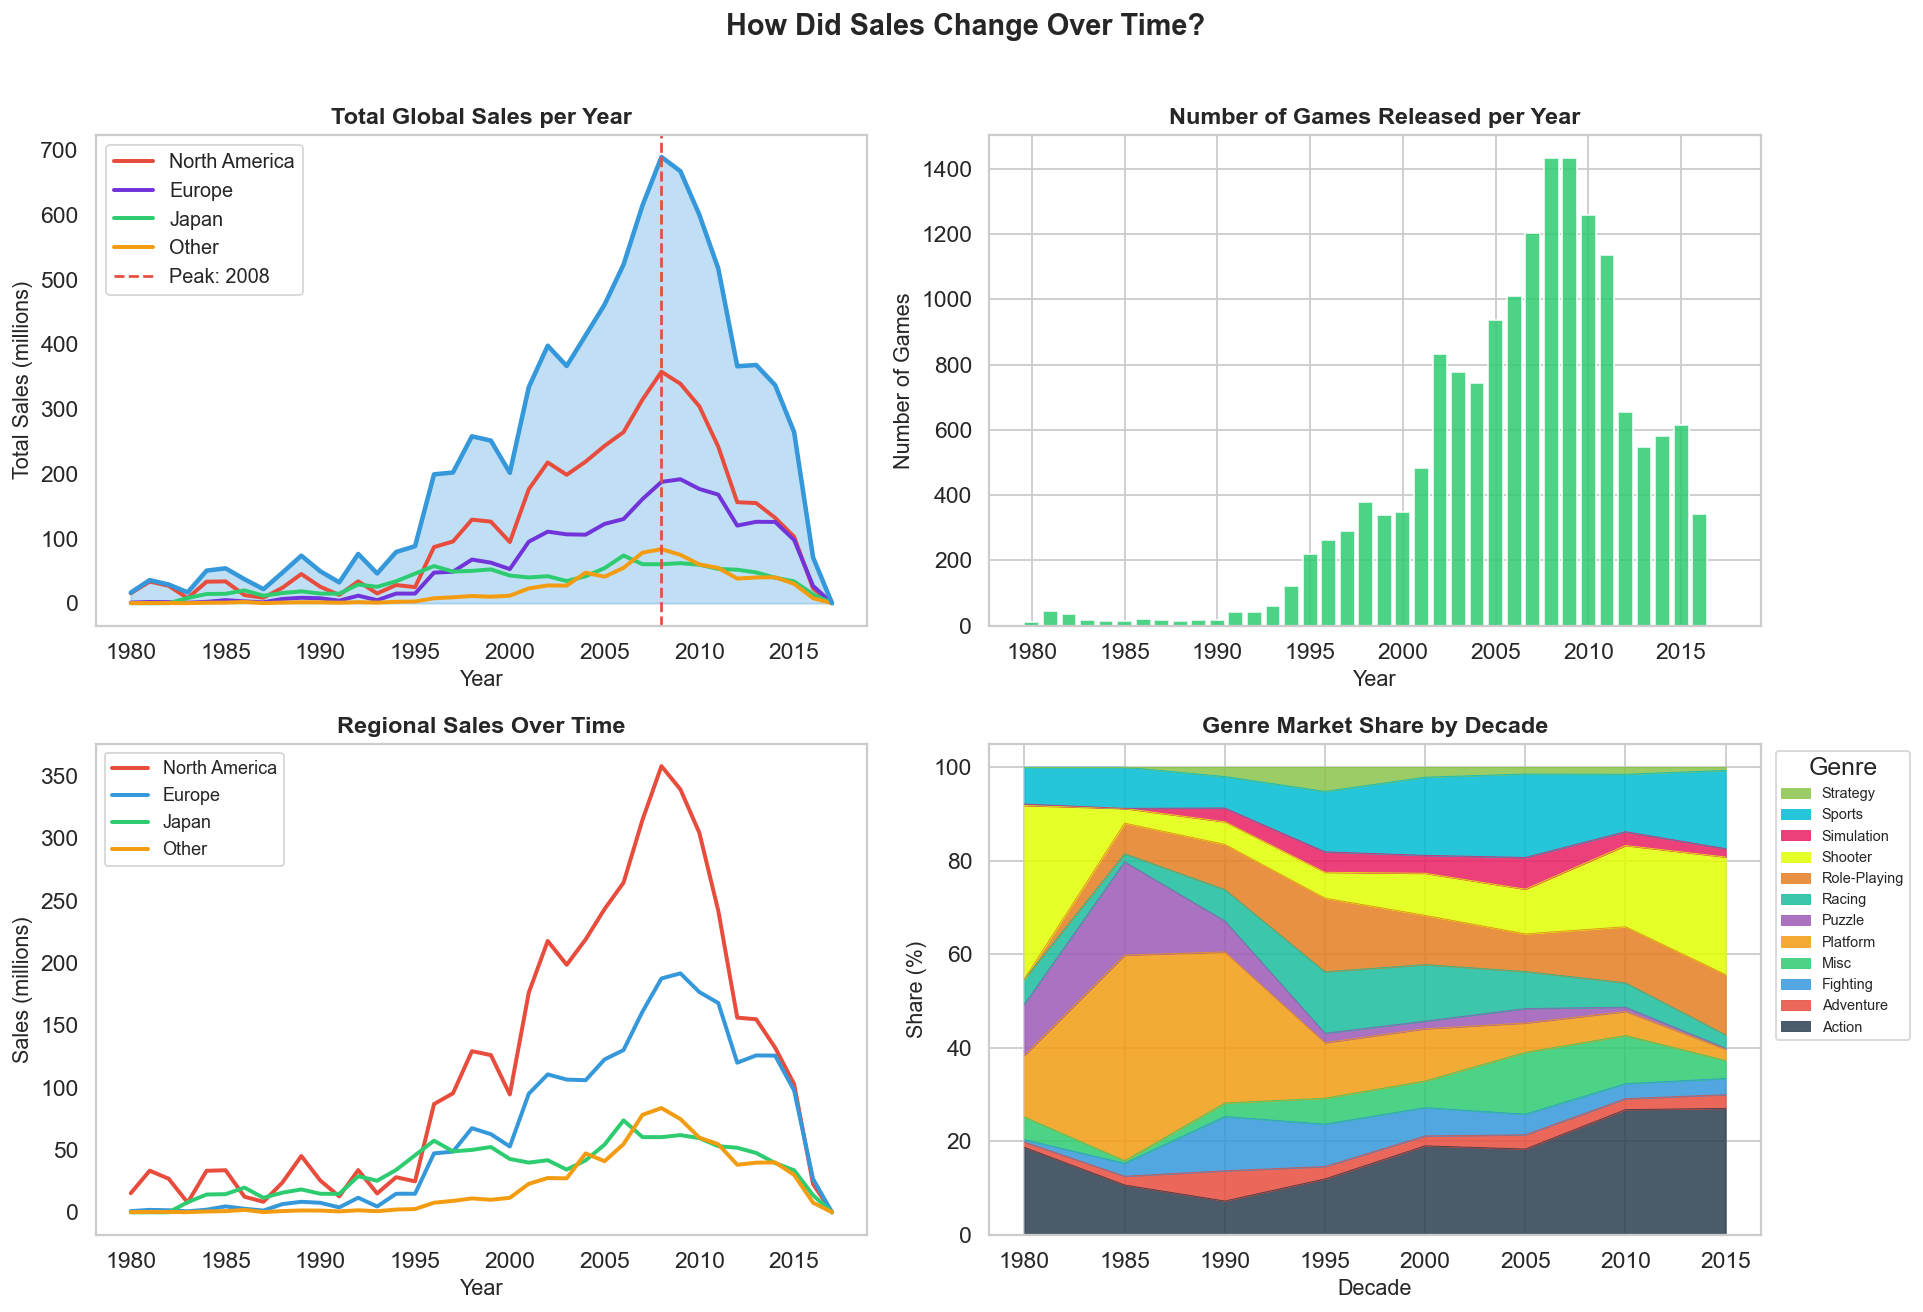

In [46]:
yearly = df.groupby('Year').agg(
    Total_Sales=('Global_Sales','sum'),
    Num_Games=('Name','count'),
    Avg_Sales=('Global_Sales','mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Total sales per year
ax = axes[0,0]
ax.fill_between(yearly['Year'], yearly['Total_Sales'],
                alpha=0.3, color='#3498DB')
reg_yearly = df.groupby('Year')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
colors_r = ['#E74C3C',"#7134DB",'#2ECC71','#F39C12']
labels_r = ['North America','Europe','Japan','Other']
for col, color, label in zip(reg_yearly.columns, colors_r, labels_r):
    ax.plot(reg_yearly.index, reg_yearly[col],
            color=color, linewidth=2.2, label=label)
ax.plot(yearly['Year'], yearly['Total_Sales'],
        color='#3498DB', linewidth=2.5)
ax.set_title('Total Global Sales per Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Sales (millions)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.grid(False)
peak_year = yearly.loc[yearly['Total_Sales'].idxmax(), 'Year']
ax.axvline(peak_year, color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f'Peak: {peak_year}')
ax.legend(fontsize=11)

# Games released per year
ax = axes[0,1]
ax.bar(yearly['Year'], yearly['Num_Games'],
       color='#2ECC71', edgecolor='white', alpha=0.85)
ax.set_title('Number of Games Released per Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Games', fontsize=12)
ax.set_xlabel('Year', fontsize=12)

# Regional sales over time
ax = axes[1,0]
reg_yearly = df.groupby('Year')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
colors_r = ['#E74C3C','#3498DB','#2ECC71','#F39C12']
labels_r = ['North America','Europe','Japan','Other']
for col, color, label in zip(reg_yearly.columns, colors_r, labels_r):
    ax.plot(reg_yearly.index, reg_yearly[col],
            color=color, linewidth=2.2, label=label)
ax.set_title('Regional Sales Over Time', fontsize=13, fontweight='bold')
ax.set_ylabel('Sales (millions)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.grid(False)
ax.legend(fontsize=10)

# Genre share over decades (stacked area)
ax = axes[1,1]
decade_genre = df.groupby(['5_Year_period','Genre'])['Global_Sales'].sum().unstack(fill_value=0)
decade_genre_pct = decade_genre.div(decade_genre.sum(axis=1), axis=0) * 100
decade_genre_pct.plot(kind='area', stacked=True, ax=ax,
                      color=PALETTE[:12], alpha=0.85, linewidth=0.5)
ax.set_title('Genre Market Share by Decade', fontsize=13, fontweight='bold')
ax.set_ylabel('Share (%)', fontsize=12)
ax.set_xlabel('Decade', fontsize=12)
 #labels starts upside down so reversed the order of colors
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],title='Genre', bbox_to_anchor=(1.01,1), fontsize=8,)
ax.set_xticks(decade_genre_pct.index)
ax.set_xticklabels([f'{d}' for d in decade_genre_pct.index])

plt.suptitle(' How Did Sales Change Over Time?',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Research question 5: What genres are most popular?

In [ ]:
# print distribution of sales by genre and test if they differ significantly

genre_stats = df.groupby('Genre').agg(
    Total_Sales=('Global_Sales','sum'),
    Num_Games=('Name','count')
).sort_values('Total_Sales', ascending=False)
genre_stats['Share_%'] = (genre_stats['Total_Sales'] /
                           genre_stats['Total_Sales'].sum() * 100).round(1)
print(genre_stats.round(2).to_string())

# ANOVA test — do genres differ in sales?
groups = [g['Global_Sales'].values for _, g in df.groupby('Genre')]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"\nANOVA:          F={f_stat:.2f}, p={p_anova:.2e}")

              Total_Sales  Num_Games  Share_%
Genre                                        
Action            1734.56       3258     19.6
Sports            1319.42       2306     14.9
Shooter           1032.62       1285     11.7
Role-Playing       923.83       1470     10.4
Platform           830.16        876      9.4
Misc               798.40       1691      9.0
Racing             727.98       1226      8.2
Fighting           447.05        837      5.0
Simulation         389.98        848      4.4
Puzzle             242.21        570      2.7
Adventure          238.28       1276      2.7
Strategy           173.27        670      2.0

ANOVA:          F=18.16, p=1.42e-36


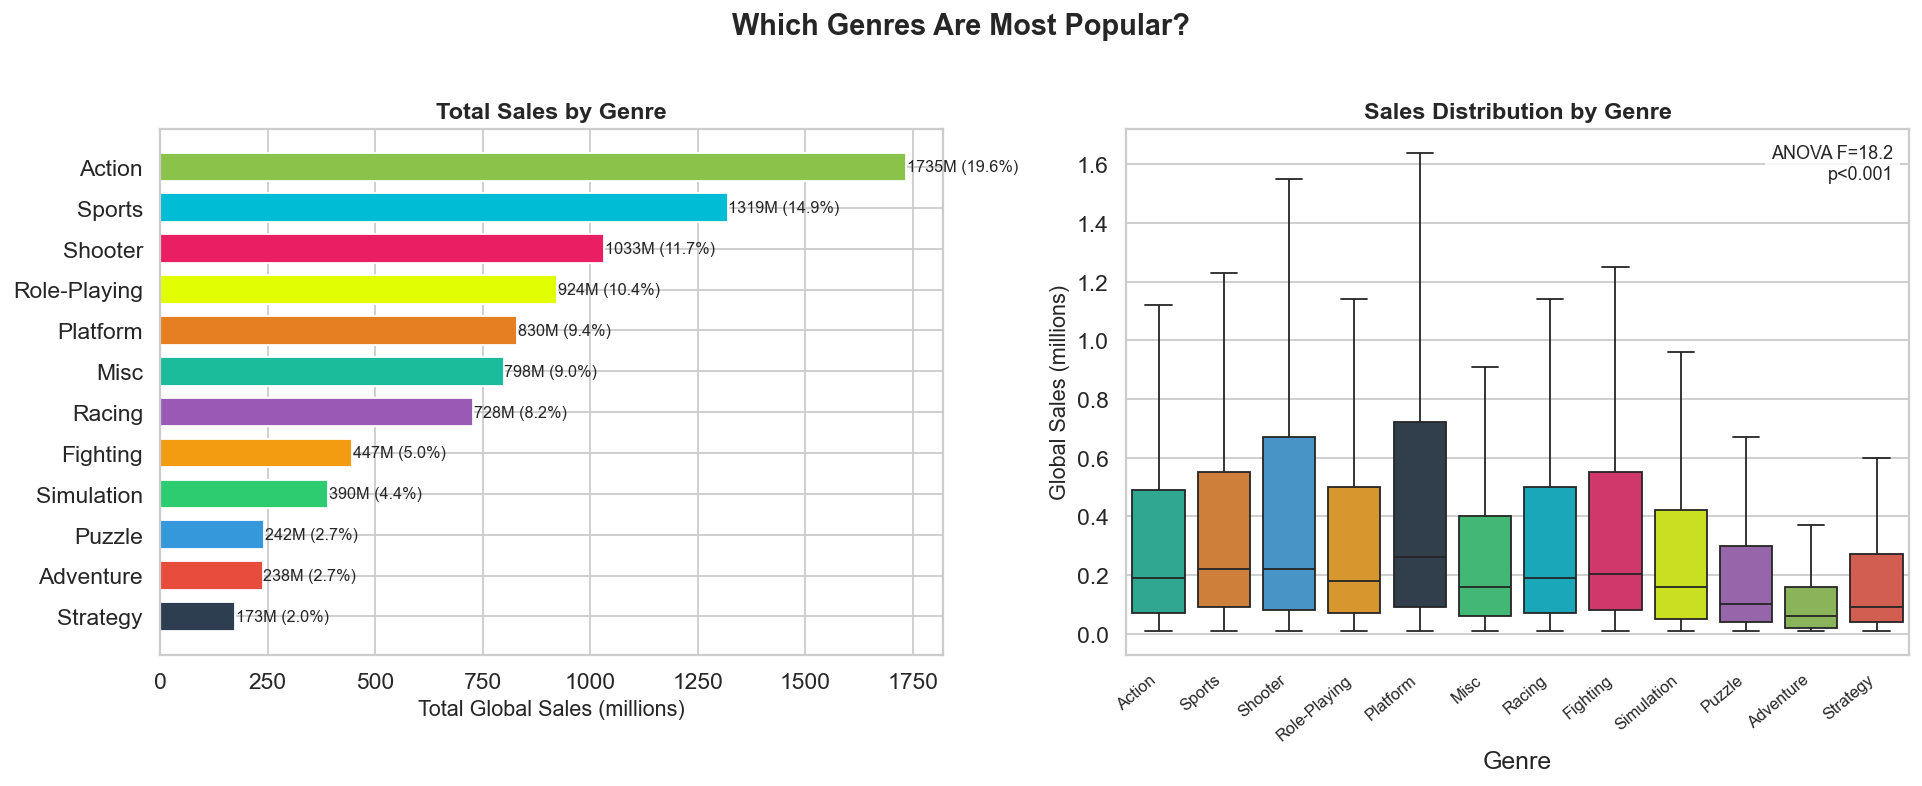

In [ ]:
# plot total sales by genre and distribution of sales by genre

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Total sales bar
ax = axes[0]
gs_sorted = genre_stats['Total_Sales'].sort_values()
ax.barh(gs_sorted.index, gs_sorted.values,
        color=PALETTE[:len(gs_sorted)], edgecolor='white', height=0.7)
for i, (idx, val) in enumerate(gs_sorted.items()):
    ax.text(val+2, i, f'{val:.0f}M ({genre_stats.loc[idx,"Share_%"]}%)',
            va='center', fontsize=9)
ax.set_xlabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Total Sales by Genre', fontsize=13, fontweight='bold')

# Box plot
ax = axes[1]
genre_order = genre_stats.index.tolist()
df_clip = df[df['Global_Sales'] < df['Global_Sales'].quantile(0.99)]
sns.boxplot(data=df_clip, x='Genre', y='Global_Sales',
            order=genre_order, palette=PALETTE[:12],
            ax=ax, hue='Genre', legend=False,showfliers=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Global Sales (millions)', fontsize=12)
ax.set_title('Sales Distribution by Genre',
             fontsize=13, fontweight='bold')
ax.text(0.98, 0.97, f'ANOVA F={f_stat:.1f}\np<0.001',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.suptitle('Which Genres Are Most Popular?',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Research question 6: How does the plattform a game is developed for depend on the genre?

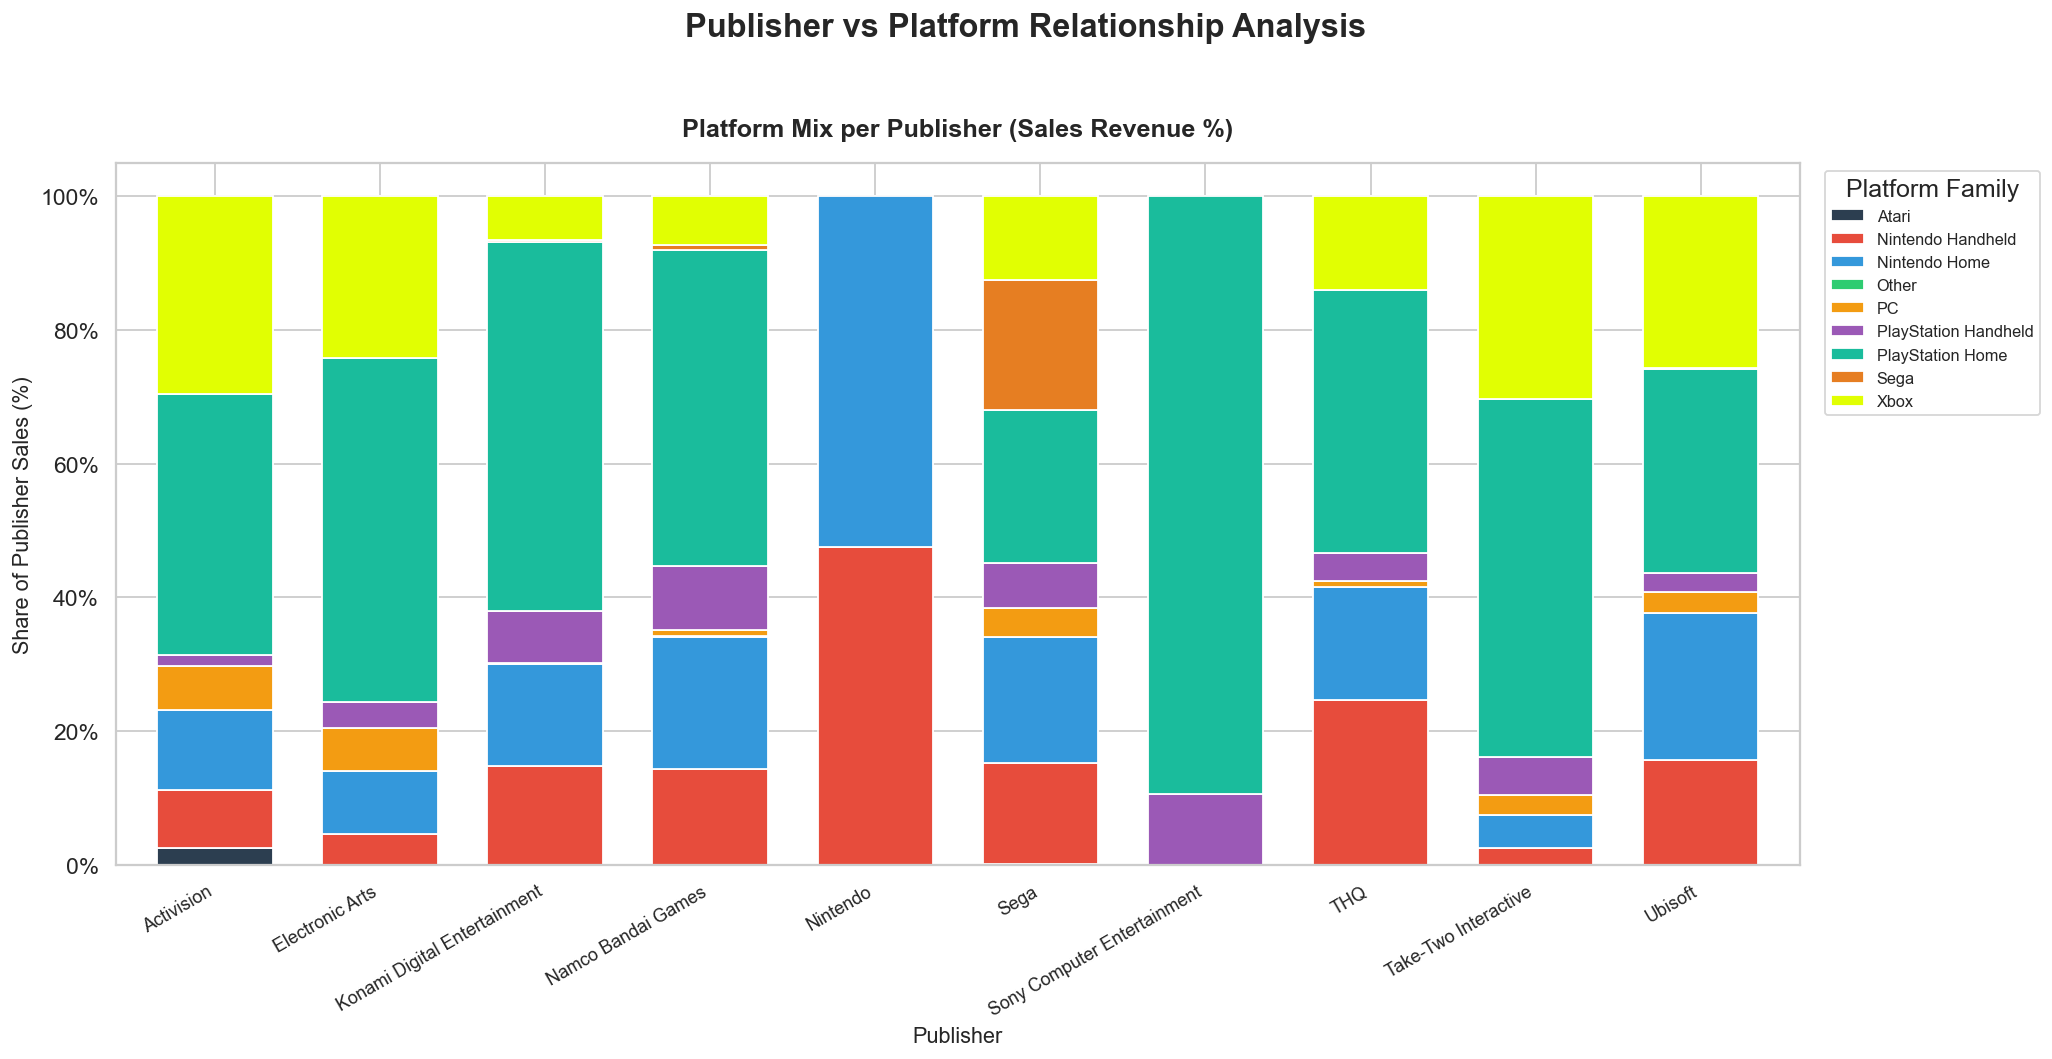

In [49]:
# Plot genre distribution of sales by publisher for top 10 publishers. This will show if some publishers are more focused on specific genres or have a more balanced portfolio

top10_pub = df['Publisher'].value_counts().head(10).index.tolist()
df_top = df[df['Publisher'].isin(top10_pub)].copy()

# Create a pivot table of Global Sales
pivot_pp = df_top.pivot_table(
    values='Global_Sales', 
    index='Publisher',
    columns='Platform_Family', 
    aggfunc='sum', 
    fill_value=0
)

# Normalize by row (Publisher) so each bar represents 100% of that publisher's output
pivot_pct = pivot_pp.div(pivot_pp.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 8))

# Plot the stacked bar chart
pivot_pct.plot(
    kind='bar', 
    stacked=True, 
    ax=ax,
    color=PALETTE[:len(pivot_pct.columns)], 
    edgecolor='white', 
    width=0.7
)

# Formatting labels and titles
ax.set_ylabel('Share of Publisher Sales (%)', fontsize=12)
ax.set_xlabel('Publisher', fontsize=12)
ax.set_title('Platform Mix per Publisher (Sales Revenue %)', 
             fontsize=14, fontweight='bold', pad=15)

# Clean up X-axis labels (rotates publisher names for readability)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)

# Formatting the Y-axis to show percentages and placing the legend outside
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='Platform Family', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.suptitle('Publisher vs Platform Relationship Analysis', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Research question 7: Which game series is the most popular?
As mentioned in the beginning we notice that a lot of games are part of a series. Being part of a series might have an effect on the popularity. For sure it makes sense to look at series in a aggregated manner.

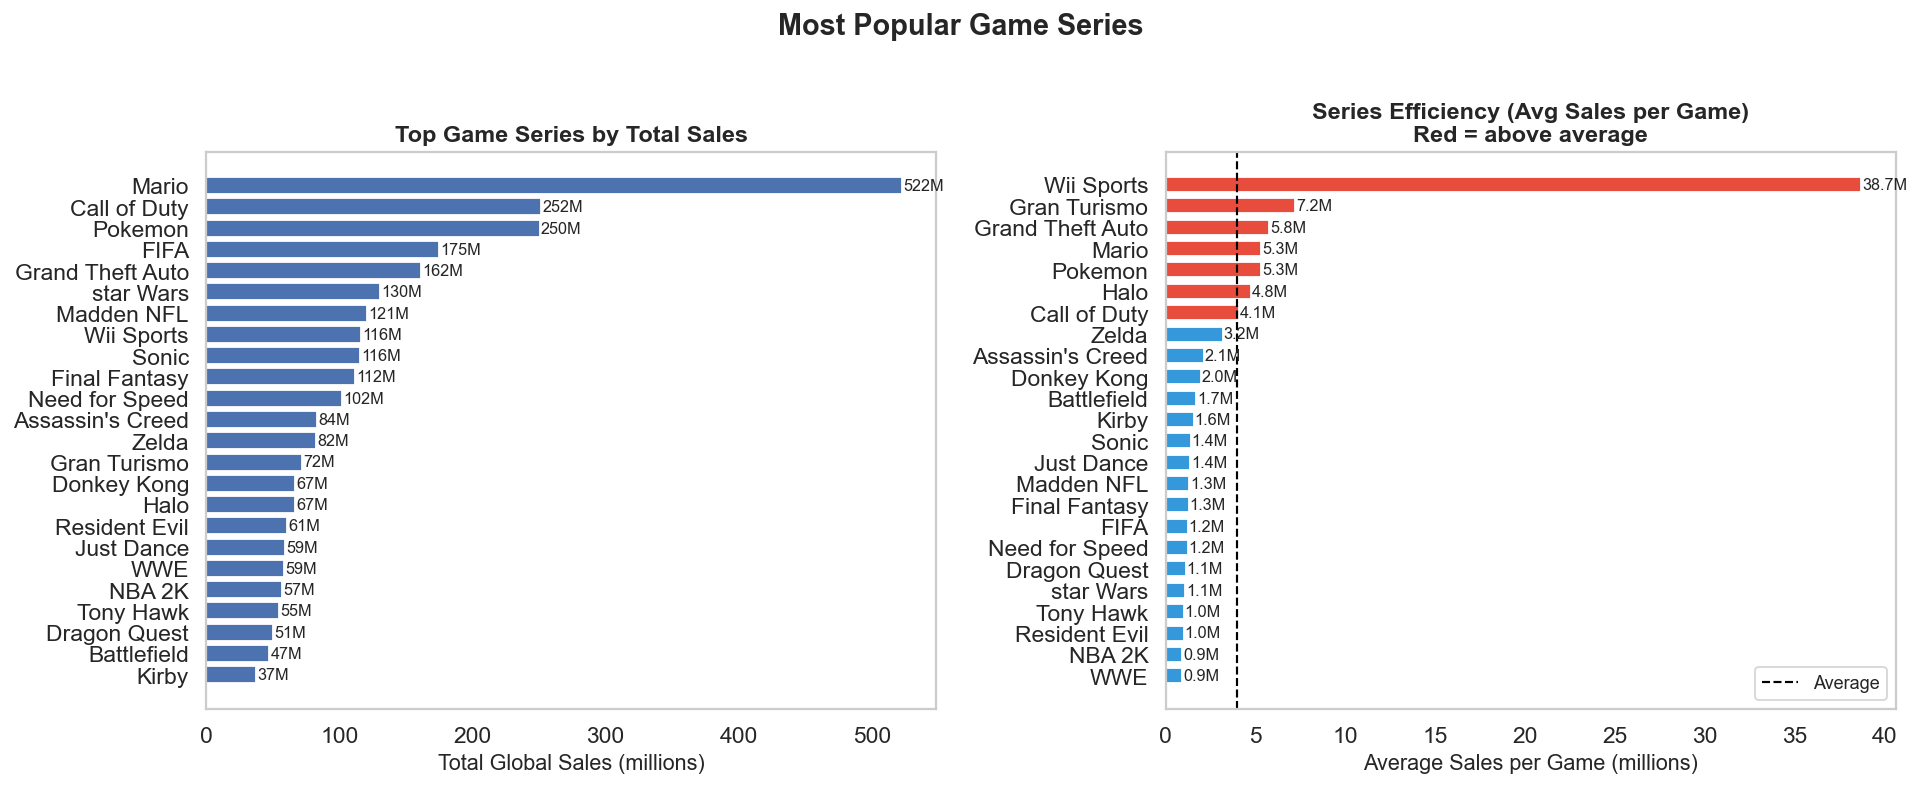

In [50]:
series_stats = df[df['Game_Series'] != 'Standalone'].groupby('Game_Series').agg(
    Total_Sales=('Global_Sales','sum'),
    Num_Games=('Name','count'),
    Avg_Per_Game=('Global_Sales','mean'),
    First_Year=('Year','min'),
    Last_Year=('Year','max')
).sort_values('Total_Sales', ascending=False)
series_stats['Lifespan'] = series_stats['Last_Year'] - series_stats['First_Year']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Total sales by series
ax = axes[0]
ax.grid(False)
ss_sorted = series_stats['Total_Sales'].sort_values()
bars = ax.barh(ss_sorted.index, ss_sorted.values)
for bar, val in zip(bars, ss_sorted.values):
    ax.text(val+1, bar.get_y()+bar.get_height()/2,
            f'{val:.0f}M', va='center', fontsize=9)
ax.set_xlabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Top Game Series by Total Sales', fontsize=13, fontweight='bold')

# Avg sales per game by series (efficiency)
ax = axes[1]
avg_sorted = series_stats['Avg_Per_Game'].sort_values()
colors_a   = ['#E74C3C' if v > series_stats['Avg_Per_Game'].mean()
               else '#3498DB' for v in avg_sorted]
bars = ax.barh(avg_sorted.index, avg_sorted.values,
               color=colors_a, edgecolor='white', height=0.7)
ax.axvline(series_stats['Avg_Per_Game'].mean(), color='black',
           linewidth=1.2, linestyle='--', label='Average')
for bar, val in zip(bars, avg_sorted.values):
    ax.text(val+0.05, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}M', va='center', fontsize=9)
ax.set_xlabel('Average Sales per Game (millions)', fontsize=12)
ax.set_title('Series Efficiency (Avg Sales per Game)\nRed = above average',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(False)

plt.suptitle('Most Popular Game Series',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Research question 8: Are game series more successful than individual standalone games?


  Series games     : 1,350  median=0.890M  mean=2.115M
  Standalone games : 14,963  median=0.150M  mean=0.401M

  Mann-Whitney U   : 16097906
  p-value (1-tail) : 2.3499e-287
  Effect size r    : -0.5938
  Result           : Series > Standalone SIGNIFICANT ✓


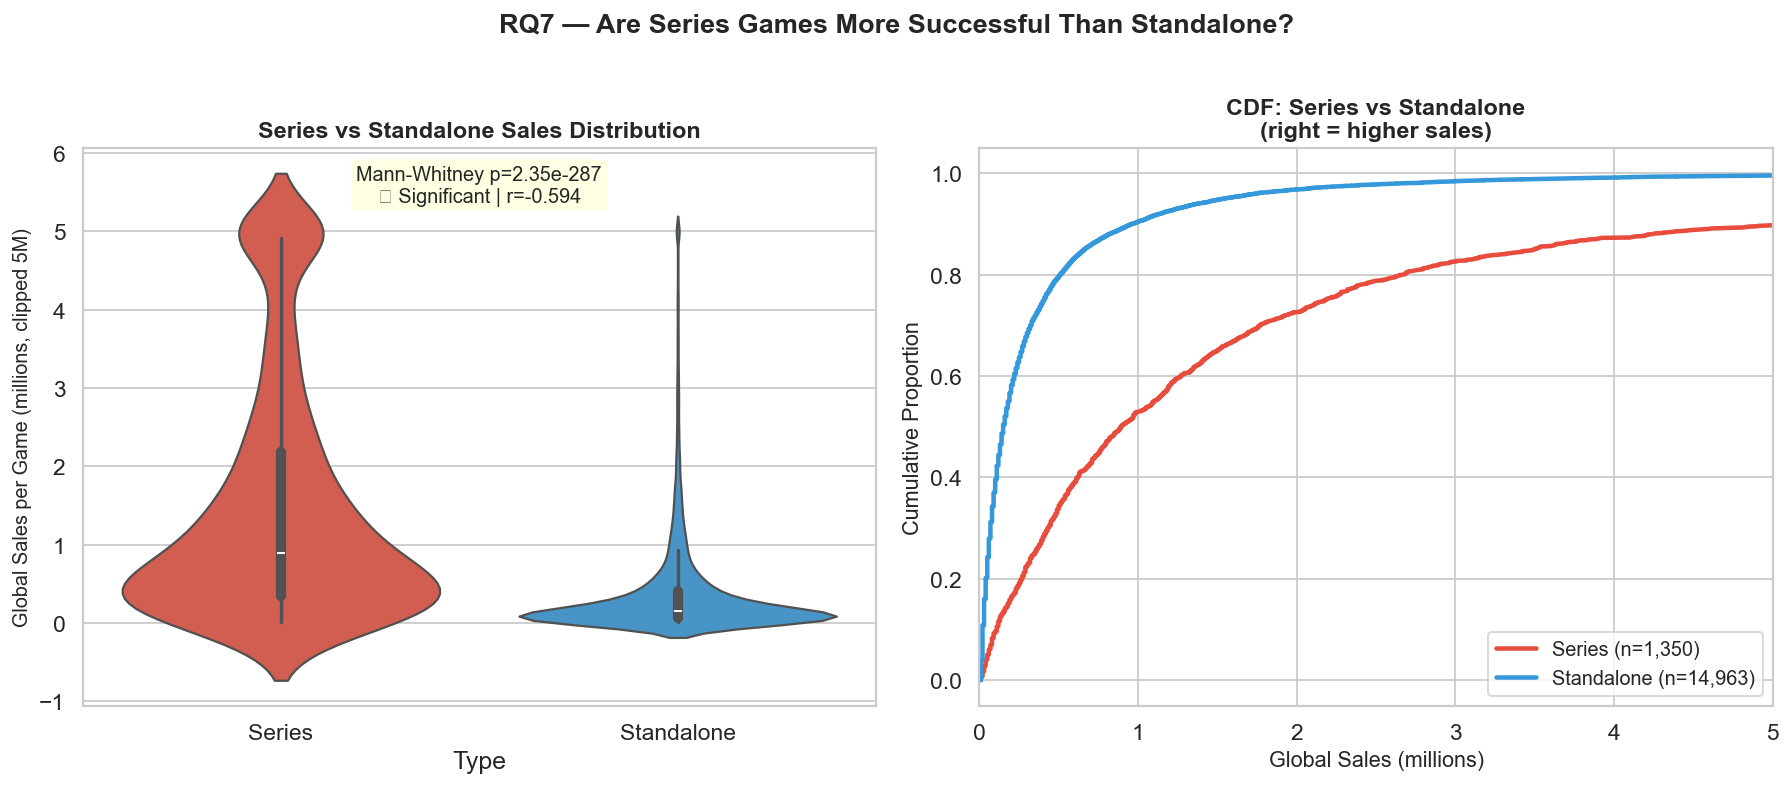

In [ ]:
# plot violin chart of series and standalone sales and test if they differ significantly

df['Is_Series'] = df['Game_Series'] != 'Standalone'
series_sales    = df[df['Is_Series']]['Global_Sales']
standalone_sales= df[~df['Is_Series']]['Global_Sales']

u_stat, p_mw = stats.mannwhitneyu(series_sales, standalone_sales,
                                   alternative='greater')
n1, n2 = len(series_sales), len(standalone_sales)
effect_r = 1 - (2*u_stat)/(n1*n2)

print(f"\n  Series games     : {n1:,}  median={series_sales.median():.3f}M  mean={series_sales.mean():.3f}M")
print(f"  Standalone games : {n2:,}  median={standalone_sales.median():.3f}M  mean={standalone_sales.mean():.3f}M")
print(f"\n  Mann-Whitney U   : {u_stat:.0f}")
print(f"  p-value (1-tail) : {p_mw:.4e}")
print(f"  Effect size r    : {effect_r:.4f}")
print(f"  Result           : {'Series > Standalone SIGNIFICANT ✓' if p_mw<0.05 else 'Not significant'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin
ax = axes[0]
plot_df = pd.DataFrame({
    'Sales': pd.concat([series_sales.clip(upper=5), standalone_sales.clip(upper=5)]),
    'Type': ['Series']*n1 + ['Standalone']*n2
})
sns.violinplot(data=plot_df, x='Type', y='Sales',
               palette=['#E74C3C','#3498DB'], ax=ax, inner='box')
ax.set_ylabel('Global Sales per Game (millions, clipped 5M)', fontsize=11)
ax.set_title('Series vs Standalone Sales Distribution',
             fontsize=13, fontweight='bold')
ax.text(0.5, 0.97, f'Mann-Whitney p={p_mw:.2e}\n★ Significant | r={effect_r:.3f}',
        transform=ax.transAxes, ha='center', va='top', fontsize=11,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

# CDF
ax = axes[1]
for vals, color, label, n in [(series_sales,'#E74C3C','Series',n1),
                               (standalone_sales,'#3498DB','Standalone',n2)]:
    sv  = np.sort(vals)
    cdf = np.arange(1, len(sv)+1) / len(sv)
    ax.plot(sv, cdf, color=color, linewidth=2.5, label=f'{label} (n={n:,})')
ax.set_xlim(0, 5)
ax.set_xlabel('Global Sales (millions)', fontsize=12)
ax.set_ylabel('Cumulative Proportion', fontsize=12)
ax.set_title('CDF: Series vs Standalone\n(right = higher sales)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

plt.suptitle('RQ7 — Are Series Games More Successful Than Standalone?',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


##### This chart reveals that video games belonging to an established Series are significantly more successful and "safer" investments than Standalone titles. 
The blue line (Standalone) climbs vertically almost immediately, showing that the vast majority of these games fail to gain traction and settle at very low sales numbers. In contrast, the red line (Series) moves much further to the right, proving that these games are far more likely to cross major sales milestones like 1, 2, or 3 million units. Essentially, while a standalone game is a high-risk gamble where most titles sell very little, a game in a series benefits from a "brand cushion" that virtually guarantees higher typical sales and a much better chance of becoming a major hit.